# Two-cell design family: is "each cell at the same frequency" special?

A multi-cell cavity is normally built so that **every cell resonates at the same
frequency** -- mid cells and end cells alike. For a symmetric **2-cell** cavity that
rule is not forced by the physics: mirror symmetry already flattens the field for
*any* choice of cell shapes at a given operating frequency. So we can ask directly --
among all 2-cell designs that operate at the target frequency, is the one where the
mid and end cells share a frequency in any way special?

This example builds that family for a TESLA-shaped 2-cell at 1.3 GHz and compares
`R/Q`, `G`, the peak-field ratios and the higher-order-mode (HOM) wake across it,
marking the "both cells at the same frequency" design.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cavsim2d import EllipticalCavity
from cavsim2d.utils.printing import set_verbose

set_verbose(False)

F = 1300.0                                       # operating frequency [MHz]
TESLA = [42, 42, 12, 19, 35, 57.7, 103.353]      # A, B, a, b, Ri, L, Req  [mm]
cav = EllipticalCavity(2, TESLA, TESLA, TESLA, beampipe='both', name='TESLA_2cell')

## Build the family

`family_scan(vary='split')` holds the mid cell fixed and sweeps the end-cell length,
retuning the shared equator radius so that **every member operates at `F`**. What
changes along the family is the *split* between the mid-cell and end-cell frequencies
(reported as `mid_freq` and `end_freq`).

In [2]:
family = cav.tune.family_scan(freq=F, n=5, fraction=0.03, vary='split')
designs = family.designs
print(designs[['L_e', 'Req', 'freq [MHz]', 'mid_freq', 'end_freq']].round(3).to_string(index=False))

   L_e     Req  freq [MHz]  mid_freq  end_freq
55.969 102.635      1300.0  1310.542  1289.587
57.700 102.914      1300.0  1306.559  1293.545
59.431 103.160      1300.0  1303.028  1297.028
61.162 103.382      1300.0  1299.866  1300.135
62.893 103.579      1300.0  1297.042  1302.869


## Evaluate each member

Every design operates at 1.3 GHz. For each we run the eigenmode solver for the
fundamental figures of merit (`R/Q`, `G`, `Epk/Eacc`, `Bpk/Eacc`, field flatness) and
a wakefield pass for the HOM loss and kick factors.

In [3]:
rows = []
for c, (_, d) in zip(family.cavities_list, designs.iterrows()):
    c.eigenmode.run(mesh_config={'h': 14, 'p': 3}, n_modes=6)
    q = c.eigenmode.qois_df.query('m == 0')
    acc = q.loc[q['R/Q [Ohm]'].idxmax()]
    c.wakefield.run({'MROT': 2, 'wakelength': 20})
    w = c.wakefield.qois
    rows.append({
        'L_e': d['L_e'],
        'split': d['mid_freq'] - d['end_freq'],
        'mid_freq': d['mid_freq'], 'end_freq': d['end_freq'],
        'R/Q [Ohm]': acc['R/Q [Ohm]'], 'G [Ohm]': acc['G [Ohm]'],
        'Epk/Eacc': acc['Epk/Eacc []'], 'Bpk/Eacc': acc['Bpk/Eacc [mT/MV/m]'],
        'ff [%]': acc['ff [%]'],
        'k_loss_HOM [V/pC]': w['k_loss_HOM [V/pC]'],
        '|k_kick| [V/pC/m]': w['|k_kick| [V/pC/m]'],
    })
tab = pd.DataFrame(rows).sort_values('L_e').reset_index(drop=True)
print(tab.round(3).to_string(index=False))

   L_e  split  mid_freq  end_freq  R/Q [Ohm]  G [Ohm]  Epk/Eacc  Bpk/Eacc  ff [%]  k_loss_HOM [V/pC]  |k_kick| [V/pC/m]
55.969 20.955  1310.542  1289.587    231.888  269.267     1.968     4.165  99.999              0.055              10.55
57.700 13.013  1306.559  1293.545    229.578  271.397     1.979     4.148 100.000              0.058              10.56
59.431  6.000  1303.028  1297.028    227.173  273.387     1.981     4.143 100.000              0.060              10.51
61.162 -0.269  1299.866  1300.135    224.697  275.215     2.000     4.160  99.992              0.061              10.44
62.893 -5.827  1297.042  1302.869    222.152  277.004     2.001     4.178  99.994              0.063              10.41


## The "both cells equal" design

The design where the mid- and end-cell frequencies coincide (`split = 0`) is the
classical each-cell-at-`F` point -- the way TESLA's end cells are matched to the mid
cells. We locate it by interpolating the split to zero.

In [4]:
order = np.argsort(tab['split'].values)
Le_star = float(np.interp(0.0, tab['split'].values[order], tab['L_e'].values[order]))
print('each-cell-at-F design:  L_e = %.3f mm   (mid_freq = end_freq)' % Le_star)

each-cell-at-F design:  L_e = 61.088 mm   (mid_freq = end_freq)


## Compare across the family

Field flatness stays ~100 % everywhere (mirror symmetry). The dashed line marks the
each-cell-at-`F` design.

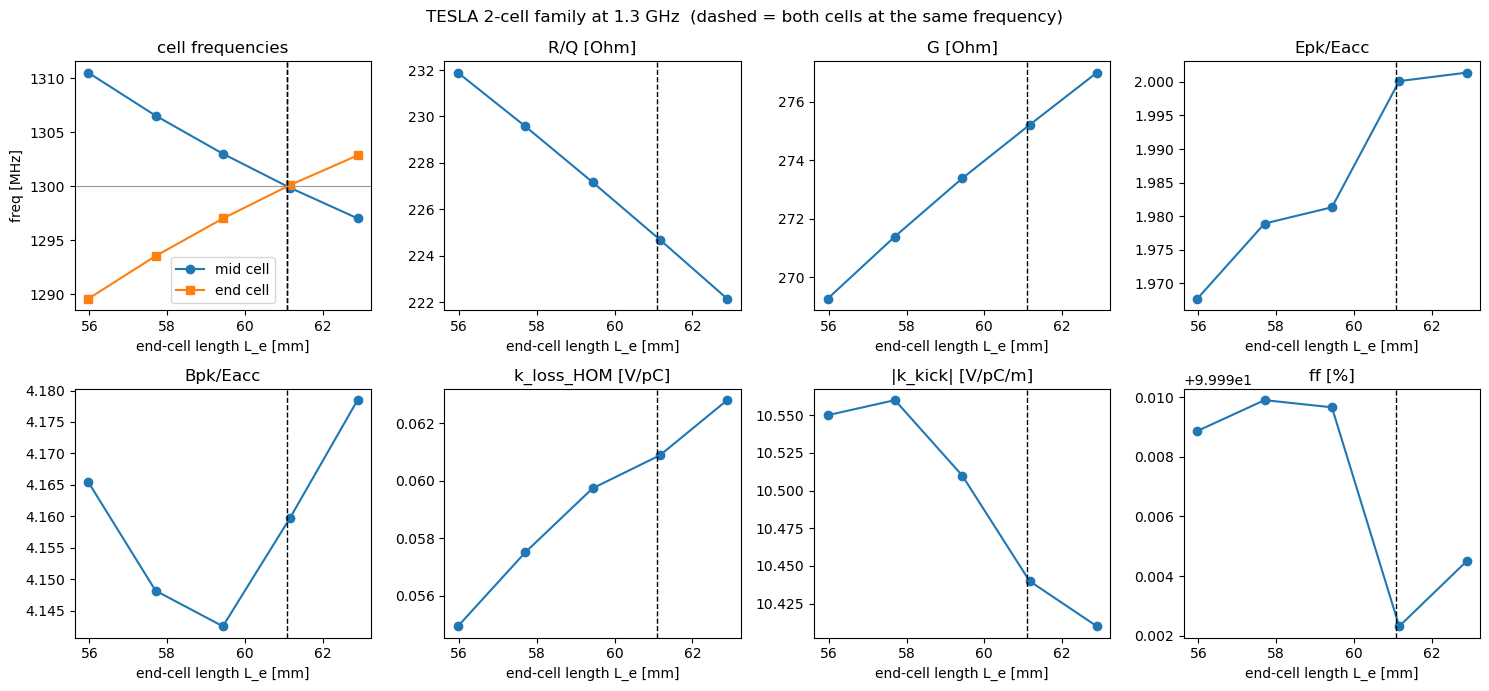

spread across the family (max-min)/mean:
  Epk/Eacc               1.7 %
  R/Q [Ohm]              4.3 %
  G [Ohm]                2.8 %
  Bpk/Eacc               0.9 %
  k_loss_HOM [V/pC]     13.3 %
  |k_kick| [V/pC/m]      1.4 %


In [5]:
fig, ax = plt.subplots(2, 4, figsize=(15, 7))
ax = ax.ravel()
x = tab['L_e']

ax[0].plot(x, tab['mid_freq'], 'o-', label='mid cell')
ax[0].plot(x, tab['end_freq'], 's-', label='end cell')
ax[0].axhline(F, color='0.6', lw=0.8)
ax[0].set_title('cell frequencies'); ax[0].set_ylabel('freq [MHz]'); ax[0].legend()

for a, col in zip(ax[1:], ['R/Q [Ohm]', 'G [Ohm]', 'Epk/Eacc', 'Bpk/Eacc',
                           'k_loss_HOM [V/pC]', '|k_kick| [V/pC/m]', 'ff [%]']):
    a.plot(x, tab[col], 'o-')
    a.set_title(col)

for a in ax:
    a.axvline(Le_star, ls='--', color='k', lw=1)
    a.set_xlabel('end-cell length L_e [mm]')
ax[0].axvline(Le_star, ls='--', color='k', lw=1)
fig.suptitle('TESLA 2-cell family at 1.3 GHz  (dashed = both cells at the same frequency)')
plt.tight_layout(); plt.show()

span = lambda s: 100 * (tab[s].max() - tab[s].min()) / tab[s].mean()
print('spread across the family (max-min)/mean:')
for s in ['Epk/Eacc', 'R/Q [Ohm]', 'G [Ohm]', 'Bpk/Eacc', 'k_loss_HOM [V/pC]', '|k_kick| [V/pC/m]']:
    print('  %-20s %5.1f %%' % (s, span(s)))

## Takeaways

- For a symmetric 2-cell, **every** design in this family operates at 1.3 GHz with a
  flat field -- mirror symmetry does the flattening, not the cell frequencies.
- **Every** figure of merit passes *smoothly* through the each-cell-at-`F` design
  (dashed line) -- there is no peak, kink or extremum there. The peak-field ratios
  `Epk/Eacc` and `Bpk/Eacc` barely move (~1-2 % across the family), while `R/Q`, `G`
  and especially the HOM loss factor `k_loss_HOM` (~13 %) vary. So the "both cells at
  the same frequency" design is one member among many, with no intrinsic advantage --
  it is the leftover shape freedom, not the cell-frequency rule, that trades these off.
  (The complementary `vary='shape'` mode of `family_scan` sweeps that shape freedom
  directly, at fixed frequency and flatness.)
- Requiring each cell to independently reach the target frequency is therefore an
  *optional* constraint for a 2-cell, not a requirement. It also **stiffens** the
  design problem: for strongly-coupled (wide-iris) cavities a cell can be unable to
  reach the target frequency on its own even when the assembly can -- so enforcing the
  rule can turn a solvable tune into an unsolvable one.